In [1]:
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.pylab import mpl
import numpy as np
import pandas as pd
import pickle
import copy
from data_evaluation_API import data_evaluation as eval
from Influxdb_API.Influxdb_API import ClientInfluxdb
%matplotlib inline

# 1. 以单组数据为例
### 1.1 从Influxdb_API获取数据
以电表数据为例  

In [2]:
db_name = 'moserveribms'
params = {
    'measurement_name': 'ibmsV2modata',
    'start_time': pd.to_datetime('2022-07-01 00:00:00'),
    'end_time': pd.to_datetime('2022-10-01 00:00:00'),
    'field_list': ['E'],
    'tag_dict': {'nid': 'ibmsv2/ibmsv2_5929149262402256896/EMeter/mDev_EMeter_Roof_MDV_10'},
    'fore': False,
    'fore_horizon': None,
    'interval': None
}
db_client = ClientInfluxdb(db_name=db_name) 
df = db_client.read_influxdb(**params)
print('data acquired\n------------------')

data acquired
------------------


### 1.2 设定相关处理参数，对数据进行必要的前处理
将从数据库中获取的数据的字符类型转换为float类型  
进行重采样

In [3]:
params_process={
    'rsp_time': pd.Timedelta('15 min'),
    'rsp_num': 4, # 4 times per hour, depends on rsp_time
    'step': 4*24*3,  # step=4/h*24h/day*3day means to calculate the missing rate three days forward at each moment
    'ms_thresh': 0.2, # the condition of missing rate (< ms_thresh) for multivariables
    'imputation_time_delta': pd.Timedelta('6 hours'), # data missing for more than consecutive imputation_time_delta will not be imputation.
    'window': 4*24*3, # window_size of remove outliers
}
# str -> np.float64
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')
# resampling data, rsp_time=15min
df = eval.resampling(df, **params_process)
print(df)

                           E
2022-07-01 00:00:00  1051.71
2022-07-01 00:15:00  1051.92
2022-07-01 00:30:00  1051.92
2022-07-01 00:45:00  1052.11
2022-07-01 01:00:00  1052.11
...                      ...
2022-09-30 12:00:00      NaN
2022-09-30 12:15:00      NaN
2022-09-30 12:30:00      NaN
2022-09-30 12:45:00  3038.98
2022-09-30 13:00:00  3038.98

[8789 rows x 1 columns]


### 1.3 计算原始数据/去除异常值数据/数据插补后的数据缺失率，并输出最优最近的时刻
params_process['step'] = 4/h * 24h/day * 3day 表示计算每个时刻向前回溯3天的数据缺失率

1.3.1 计算原始数据的数据缺失率

E minimal missing rate:  0.0
E average missing rate:  0.5462837859192645
E the closest optimal moment to the present:  2022-09-07 14:15:00 
------------------


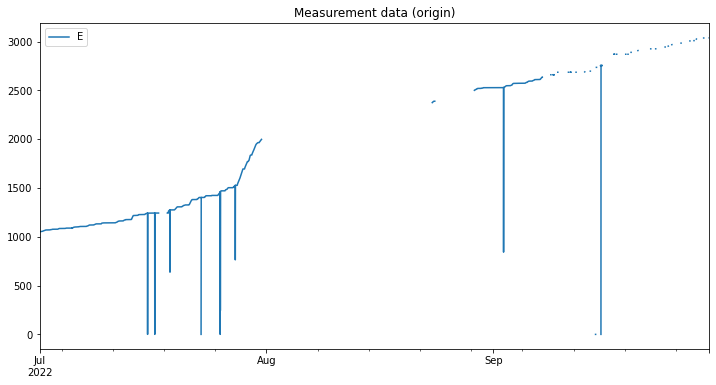

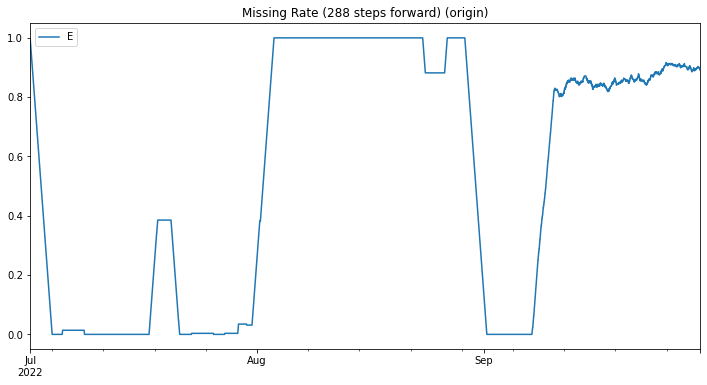

In [4]:
missing_rate = eval.cal_missing_rate(df, **params_process, plot=True, mark='origin')

1.3.2 计算去除异常值后的数据缺失率

E minimal missing rate:  0.0
E average missing rate:  0.5490144720041426
E the closest optimal moment to the present:  2022-09-07 14:00:00 
------------------


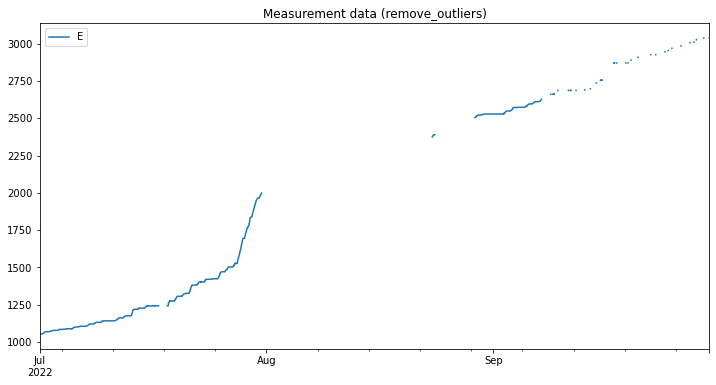

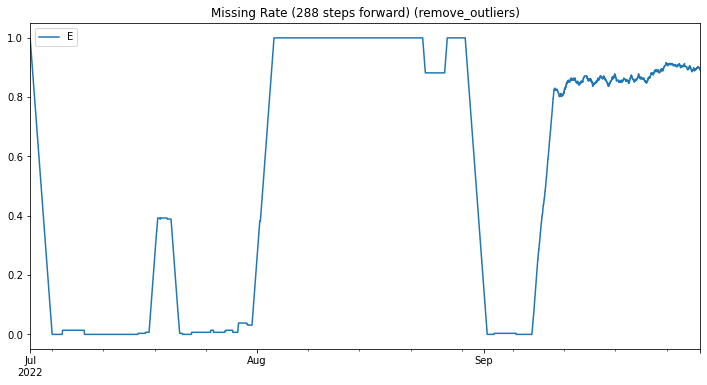

In [5]:
df_process = eval.remove_outliers(df, **params_process)
missing_rate_process = eval.cal_missing_rate(df_process, **params_process, plot=True, mark='remove_outliers')

1.3.3 计算数据插补后的数据缺失率

E minimal missing rate:  0.0
E average missing rate:  0.38055342220704924
E the closest optimal moment to the present:  2022-09-23 05:15:00 
------------------


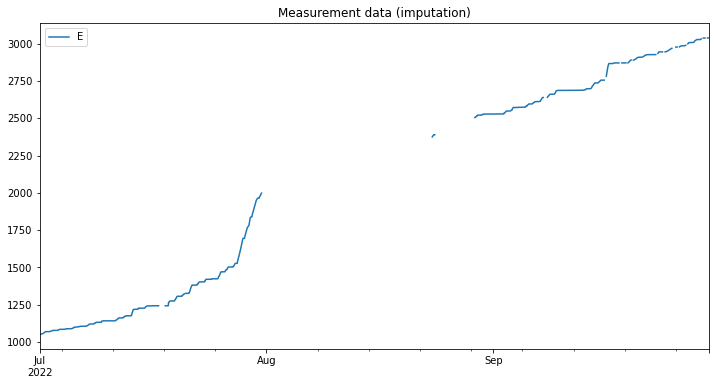

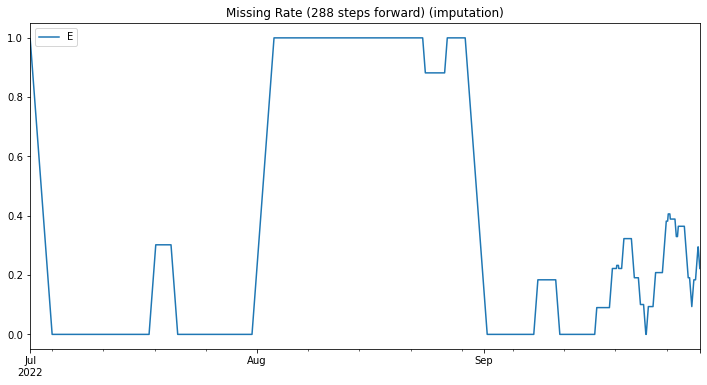

In [6]:
df_new = eval.linear_imputation(df_process, **params_process)
missing_rate_new = eval.cal_missing_rate(df_new, **params_process, plot=True, mark='imputation')

# 2. 以多组数据为例
### 2.1 从Influxdb_API获取数据
1K0V多联机0号室内机的温度数据与多联机用电数据与天气数据

In [7]:
data_required = {
    'moserveribms': {'ibmsV2modata':
                        {'tag_dict': 
                            {'nid': 'ibmsv2/ibmsv2_5929149262402256896/EMeter/mDev_EMeter_Roof_MDV_10'},
                        'field_list':
                            ['E']
                        },
                    'bridgemodata':
                        {'tag_dict': 
                            {'nid': 'ibms/ibms_1564376390869024768/microWeatherStation/20201800'},
                        'field_list':
                            ['e3']
                        }
    },
    'moserver': {'modata':
                    {'tag_dict': 
                        {'nid': 'vrf/vrf_0000CC311178CCM26232341000271K0V/indoor/0'},
                    'field_list':
                        ['roomTemp']
                    }
    },
}

df_list = []
for key1, value1 in data_required.items():
    for key2, value2 in value1.items():
            db_name_temp = key1
            params_temp = {
                'measurement_name': key2,
                'start_time': pd.to_datetime('2022-07-01 00:00:00'),
                'end_time': pd.to_datetime('2022-10-01 00:00:00'),
                'field_list': value2['field_list'],
                'tag_dict': value2['tag_dict'],
                'fore': False,
                'fore_horizon': None,
                'interval': None
            }
            db_client_temp = ClientInfluxdb(db_name=db_name_temp) 
            df_temp = db_client_temp.read_influxdb(**params_temp)
            # str -> np.float64
            for col in df_temp.columns:
                df_temp[col] = pd.to_numeric(df_temp[col], errors='ignore')
            # resampling data, rsp_time=15min
            df_temp = eval.resampling(df_temp)
            df_list.append(df_temp)

df = pd.concat(df_list, axis=1)

print(df)
print('Data acquired\n------------------')

                           E         e3   roomTemp
2022-07-01 00:00:00  1051.71  27.500000  30.344444
2022-07-01 00:15:00  1051.92  27.266667  30.481818
2022-07-01 00:30:00  1051.92  26.966667  30.618182
2022-07-01 00:45:00  1052.11  26.900000  30.700000
2022-07-01 01:00:00  1052.11  27.033333  30.700000
...                      ...        ...        ...
2022-09-30 22:45:00      NaN        NaN  27.910000
2022-09-30 23:00:00      NaN        NaN  28.166667
2022-09-30 23:15:00      NaN        NaN  28.520000
2022-09-30 23:30:00      NaN        NaN  28.650000
2022-09-30 23:45:00      NaN        NaN  28.133333

[8832 rows x 3 columns]
Data acquired
------------------


### 2.2 计算原始数据/去除异常值数据/数据插补后的数据缺失率，并输出“各组数据最优最近的时刻”和“所有数据满足3天缺失率低于20%的最近时刻”

E minimal missing rate:  0.0
E average missing rate:  0.5480213994565183
E the closest optimal moment to the present:  2022-09-07 14:15:00 
------------------
e3 minimal missing rate:  0.0
e3 average missing rate:  0.41531072300220895
e3 the closest optimal moment to the present:  2022-07-24 23:30:00 
------------------
roomTemp minimal missing rate:  0.0
roomTemp average missing rate:  0.45746252579005026
roomTemp the closest optimal moment to the present:  2022-09-29 14:45:00 
------------------
The closest moment meets the condition (missing rate < 0.2) for multivariables:  2022-07-31 19:45:00 
------------------




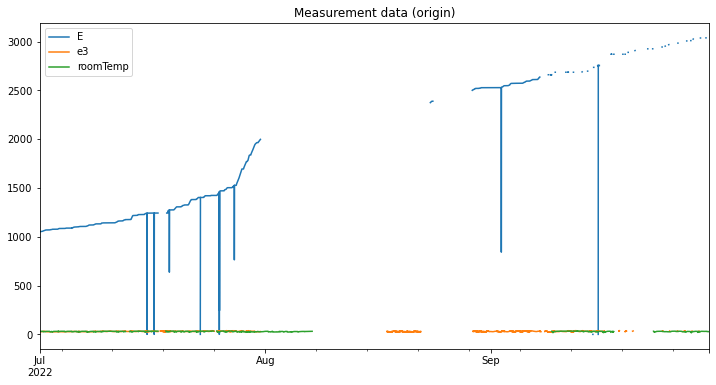

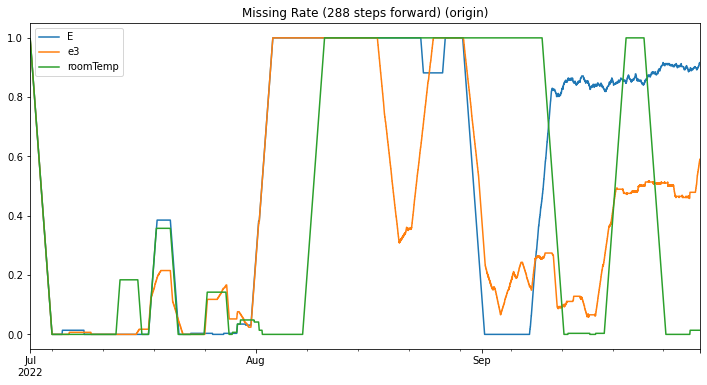

In [8]:
missing_rate = eval.cal_missing_rate(df, **params_process, plot=True, mark='origin')

E minimal missing rate:  0.0
E average missing rate:  0.5507387907608653
E the closest optimal moment to the present:  2022-09-07 14:00:00 
------------------
e3 minimal missing rate:  0.0
e3 average missing rate:  0.4159900708282948
e3 the closest optimal moment to the present:  2022-07-24 23:30:00 
------------------
roomTemp minimal missing rate:  0.0
roomTemp average missing rate:  0.46580144172705845
roomTemp the closest optimal moment to the present:  2022-09-28 12:00:00 
------------------
The closest moment meets the condition (missing rate < 0.2) for multivariables:  2022-07-31 19:45:00 
------------------




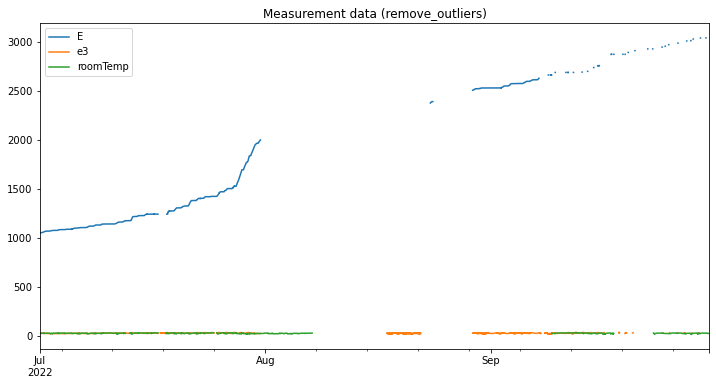

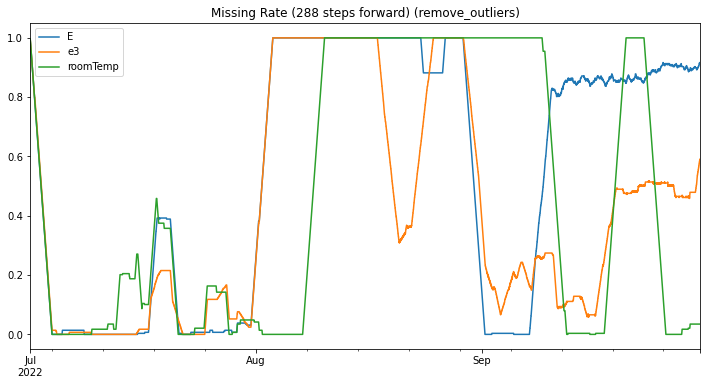

In [9]:
df_process = eval.remove_outliers(df, **params_process)
missing_rate_process = eval.cal_missing_rate(df_process, **params_process, plot=True, mark='remove_outliers')

E minimal missing rate:  0.0
E average missing rate:  0.38007387907608436
E the closest optimal moment to the present:  2022-09-23 05:15:00 
------------------
e3 minimal missing rate:  0.0
e3 average missing rate:  0.2957014738073719
e3 the closest optimal moment to the present:  2022-09-30 13:15:00 
------------------
roomTemp minimal missing rate:  0.0
roomTemp average missing rate:  0.45454030797101397
roomTemp the closest optimal moment to the present:  2022-09-30 23:45:00 
------------------
The closest moment meets the condition (missing rate < 0.2) for multivariables:  2022-09-30 00:00:00 
------------------




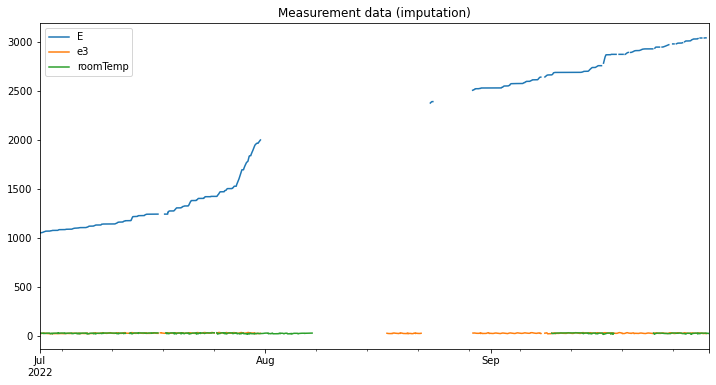

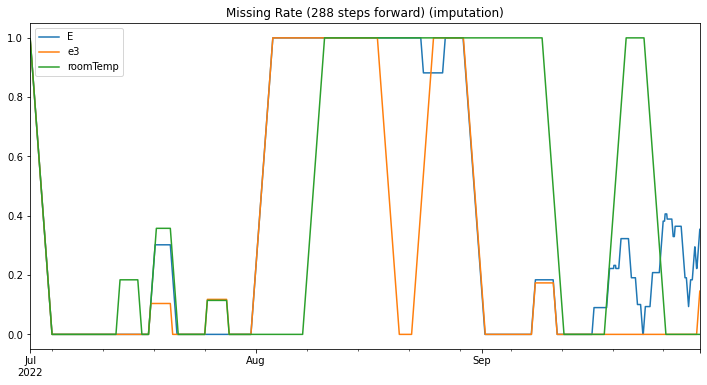

In [10]:
df_new = eval.linear_imputation(df_process, **params_process)
missing_rate_new = eval.cal_missing_rate(df_new, **params_process, plot=True, mark='imputation')